# Deteccion de Lavado de Dinero con Machine Learning


## 1. Imports y Configuracion


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    f1_score, make_scorer
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('ticks')
sns.set_context('paper', font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'figure.facecolor': 'white',
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'mathtext.fontset': 'dejavuserif',
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'lines.linewidth': 1.5,
})

PALETTE = {
    'legit'  : '#3B4CC0',   # azul  — clase legítima / valores bajos
    'fraud'  : '#B40426',   # rojo  — clase fraude    / valores altos
    'mid'    : '#DDDDDD',   # gris  — punto neutro de la escala
    'accent' : '#F2A134',   # naranja cálido — anotaciones / highlights
    'neutral': '#9E9E9E',   # gris medio — baselines, grids
}

HEATMAP_CMAP = plt.cm.coolwarm
INTENSITY_CMAP = plt.cm.Blues

## 2. Carga de Datos


In [2]:
trans = pd.read_csv('../Data/HI-Small_Trans.csv')
accounts = pd.read_csv('../Data/HI-Small_accounts.csv')

print(f"{'Dataset':<20} {'Filas':>12} {'Columnas':>10}")
print("-" * 45)
print(f"{'Transacciones (trans)':<20} {trans.shape[0]:>12,} {trans.shape[1]:>10}")
print(f"{'Cuentas (accounts)':<20} {accounts.shape[0]:>12,} {accounts.shape[1]:>10}")

Dataset                     Filas   Columnas
---------------------------------------------
Transacciones (trans)    5,078,345         11
Cuentas (accounts)        518,581          5


## 3. Analisis Exploratorio de Datos (EDA)


### 3.1 Vista General del Dataset de Transacciones


In [3]:
display(trans.head(3))
print()
print(trans.info())

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.3400,US Dollar,3697.3400,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.0100,US Dollar,0.0100,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.5700,US Dollar,14675.5700,US Dollar,Reinvestment,0



<class 'pandas.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           str    
 1   From Bank           int64  
 2   Account             str    
 3   To Bank             int64  
 4   Account.1           str    
 5   Amount Received     float64
 6   Receiving Currency  str    
 7   Amount Paid         float64
 8   Payment Currency    str    
 9   Payment Format      str    
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 426.2 MB
None


In [4]:
print("Estadisticas descriptivas de variables numericas:\n")
display(trans.describe().T.style.format('{:,.2f}').set_properties(**{'text-align': 'right'}))

Estadisticas descriptivas de variables numericas:



,count,mean,std,min,25%,50%,75%,max
From Bank,"5,078,345.00","45,730.57","81,765.62",1.00,119.00,"9,679.00","28,628.00","356,303.00"
To Bank,"5,078,345.00","65,744.56","84,092.99",1.00,"4,259.00","21,568.00","122,332.00","356,294.00"
Amount Received,"5,078,345.00","5,988,726.07","1,037,183,108.89",0.00,183.37,"1,411.01","12,346.27","1,046,302,363,293.48"
Amount Paid,"5,078,345.00","4,509,273.37","869,772,830.92",0.00,184.48,"1,414.54","12,297.84","1,046,302,363,293.48"
Is Laundering,"5,078,345.00",0.00,0.03,0.00,0.00,0.00,0.00,1.00


In [5]:
null_counts = trans.isnull().sum()
if null_counts.sum() == 0:
    print("No hay valores nulos en el dataset de transacciones.")
else:
    print("Valores nulos por columna:")
    print(null_counts[null_counts > 0])

No hay valores nulos en el dataset de transacciones.


### 3.2 Vista General del Dataset de Cuentas


In [6]:
display(accounts.head(3))
print()
print(accounts.info())

dup_count = accounts['Account Number'].duplicated().sum()
print(f"\nCuentas unicas:                {accounts['Account Number'].nunique():,}")
print(f"Filas duplicadas (Account Number): {dup_count}")

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397



<class 'pandas.DataFrame'>
RangeIndex: 518581 entries, 0 to 518580
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   Bank Name       518581 non-null  str  
 1   Bank ID         518581 non-null  int64
 2   Account Number  518581 non-null  str  
 3   Entity ID       518581 non-null  str  
 4   Entity Name     518581 non-null  str  
dtypes: int64(1), str(4)
memory usage: 19.8 MB
None

Cuentas unicas:                518,573
Filas duplicadas (Account Number): 8


### 3.3 Desbalance de Clases


Clase                    Cantidad   Porcentaje
----------------------------------------------
Legitima (0)            5,073,168     99.8981%
Lavado (1)                  5,177      0.1019%
----------------------------------------------
Total                   5,078,345

Ratio de desbalance: 980 : 1


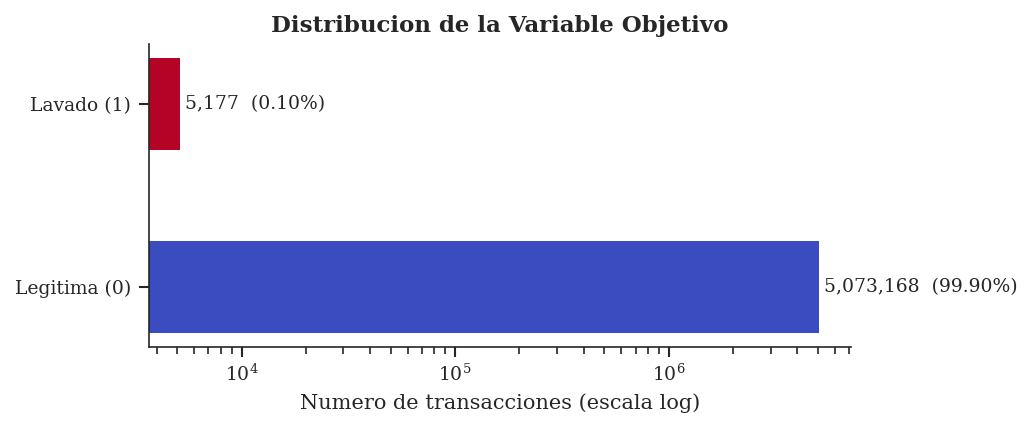

In [7]:
counts = trans['Is Laundering'].value_counts().sort_index()
pcts = trans['Is Laundering'].value_counts(normalize=True).sort_index() * 100

print(f"{'Clase':<20} {'Cantidad':>12} {'Porcentaje':>12}")
print("-" * 46)
print(f"{'Legitima (0)':<20} {counts[0]:>12,} {pcts[0]:>11.4f}%")
print(f"{'Lavado (1)':<20} {counts[1]:>12,} {pcts[1]:>11.4f}%")
print("-" * 46)
print(f"{'Total':<20} {counts.sum():>12,}")
print(f"\nRatio de desbalance: {counts[0] / counts[1]:.0f} : 1")

labels = ['Legitima (0)', 'Lavado (1)']
colors = [PALETTE['legit'], PALETTE['fraud']]

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(labels, counts.values, color=colors, edgecolor='none', height=0.5)
for bar, val, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height() / 2,
            f'{val:,}  ({pct:.2f}%)', va='center', fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('Numero de transacciones (escala log)')
ax.set_title('Distribucion de la Variable Objetivo', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()


*   Existe un desequilibrio extremo de clases.
*   El ratio de 1022:1 indica que los modelos estarán fuertemente sesgados hacia la clase mayoritaria (legítima).
*   Será fundamental utilizar métricas robustas como F1-Score o PR-AUC en la fase de modelado, y técnicas como submuestreo o ajuste de pesos (`class_weight`).

### 3.4 Distribucion de Montos


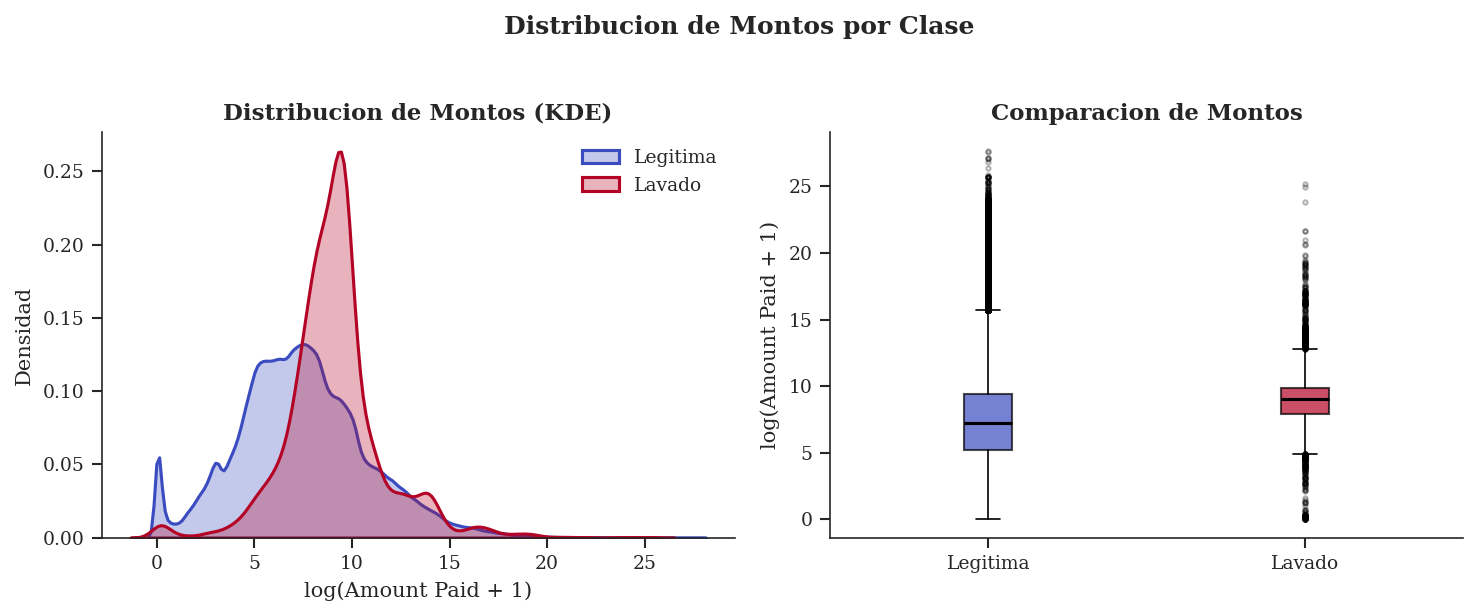

,Legitima,Lavado
count,"5,073,168.00","5,177.00"
mean,"4,477,000.04","36,135,310.41"
std,"868,846,296.80","1,527,918,669.80"
min,0.00,0.00
25%,184.16,"2,634.97"
50%,"1,410.99","8,667.21"
75%,"12,279.34","18,832.27"
max,"1,046,302,363,293.48","84,853,144,179.58"


In [8]:
legit = trans[trans['Is Laundering'] == 0]
fraud = trans[trans['Is Laundering'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# KDE superpuesto
for label, data, color in [('Legitima', legit, PALETTE['legit']),
                            ('Lavado', fraud, PALETTE['fraud'])]:
    sns.kdeplot(np.log1p(data['Amount Paid']), ax=axes[0], color=color,
                fill=True, alpha=0.3, linewidth=1.5, label=label)
axes[0].set_xlabel('log(Amount Paid + 1)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribucion de Montos (KDE)', fontweight='bold')
axes[0].legend(frameon=False)

# Boxplot comparativo
bp = axes[1].boxplot(
    [np.log1p(legit['Amount Paid']), np.log1p(fraud['Amount Paid'])],
    tick_labels=['Legitima', 'Lavado'], patch_artist=True,
    boxprops=dict(linewidth=1.0), medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(linewidth=0.8), capprops=dict(linewidth=0.8),
    flierprops=dict(markersize=2, alpha=0.3)
)
bp['boxes'][0].set_facecolor(PALETTE['legit'])
bp['boxes'][1].set_facecolor(PALETTE['fraud'])
for box in bp['boxes']:
    box.set_alpha(0.7)
axes[1].set_ylabel('log(Amount Paid + 1)')
axes[1].set_title('Comparacion de Montos', fontweight='bold')

fig.suptitle('Distribucion de Montos por Clase', fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

# Tabla comparativa
stats = pd.DataFrame({
    'Legitima': legit['Amount Paid'].describe(),
    'Lavado': fraud['Amount Paid'].describe()
})
display(stats.style.format('{:,.2f}'))


*   Ambas distribuciones tienen sesgo hacia la derecha (por eso la escala logarítmica).
*   En el caso del fraude, las transacciones tienden a tener montos más altos de forma más consistente y su varianza puede diferir.
*   Sin embargo, hay un considerable solapamiento, por lo que el monto individualmente no separará las clases perfectamente, pero sigue siendo informativo.

### 3.5 Analisis por Metodo de Pago


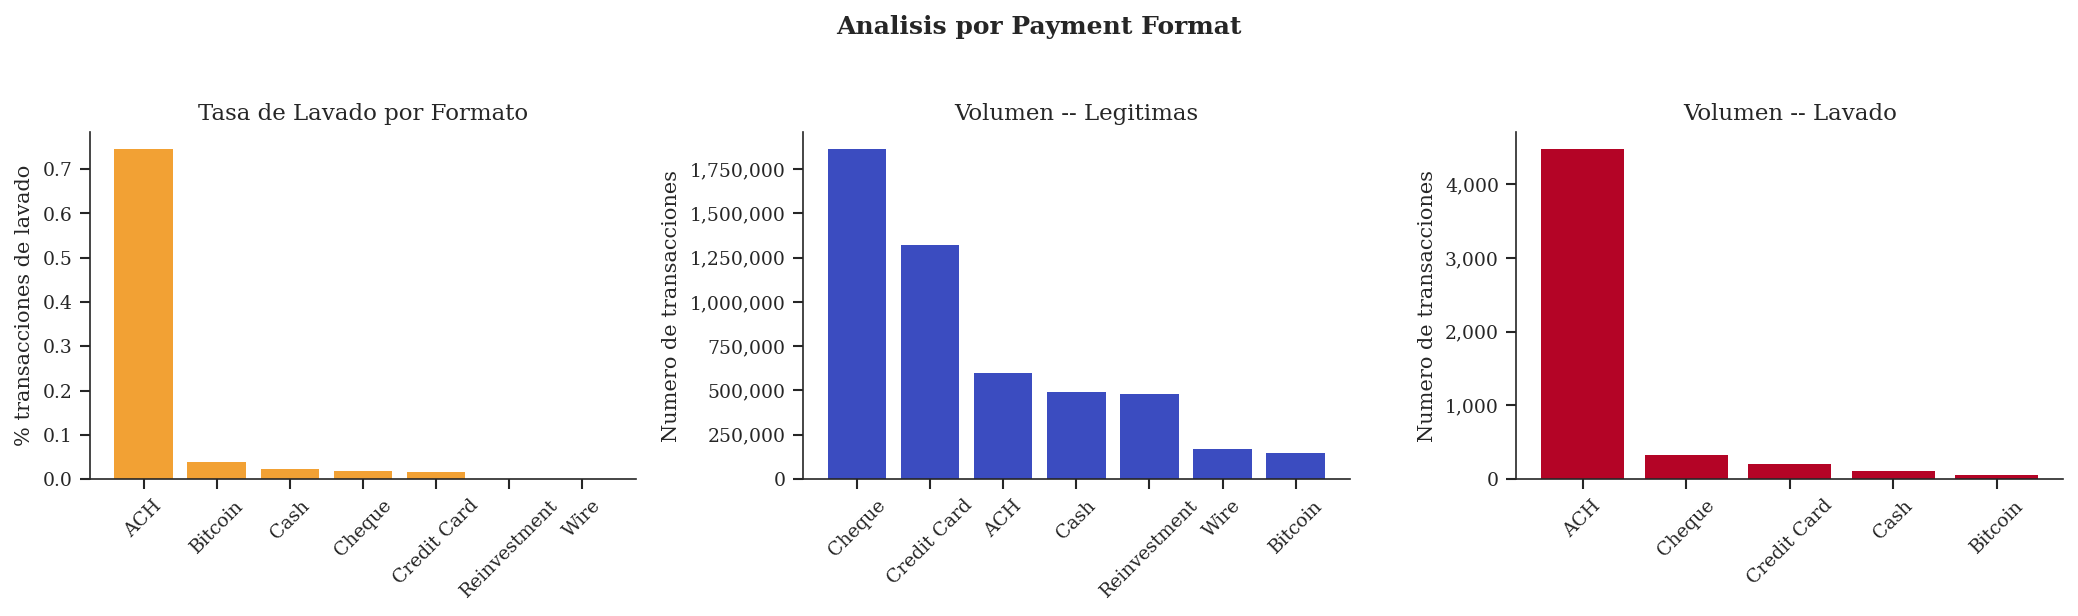

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

fraud_rate_fmt = trans.groupby('Payment Format')['Is Laundering'].mean().sort_values(ascending=False)
axes[0].bar(fraud_rate_fmt.index, fraud_rate_fmt.values * 100, color=PALETTE['accent'], edgecolor='none')
axes[0].set_title('Tasa de Lavado por Formato')
axes[0].set_ylabel('% transacciones de lavado')
axes[0].tick_params(axis='x', rotation=45)

fmt_legit = legit['Payment Format'].value_counts()
axes[1].bar(fmt_legit.index, fmt_legit.values, color=PALETTE['legit'], edgecolor='none')
axes[1].set_title('Volumen -- Legitimas')
axes[1].set_ylabel('Numero de transacciones')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].tick_params(axis='x', rotation=45)

fmt_fraud = fraud['Payment Format'].value_counts()
axes[2].bar(fmt_fraud.index, fmt_fraud.values, color=PALETTE['fraud'], edgecolor='none')
axes[2].set_title('Volumen -- Lavado')
axes[2].set_ylabel('Numero de transacciones')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[2].tick_params(axis='x', rotation=45)

fig.suptitle('Analisis por Payment Format', fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()


*   Existen formas de pago (como ACH, wire, cheque) que difieren claramente en su tasa de uso para lavar dinero.
*   Esta variable categórica podria aportar una alta capacidad predictiva por sí sola.

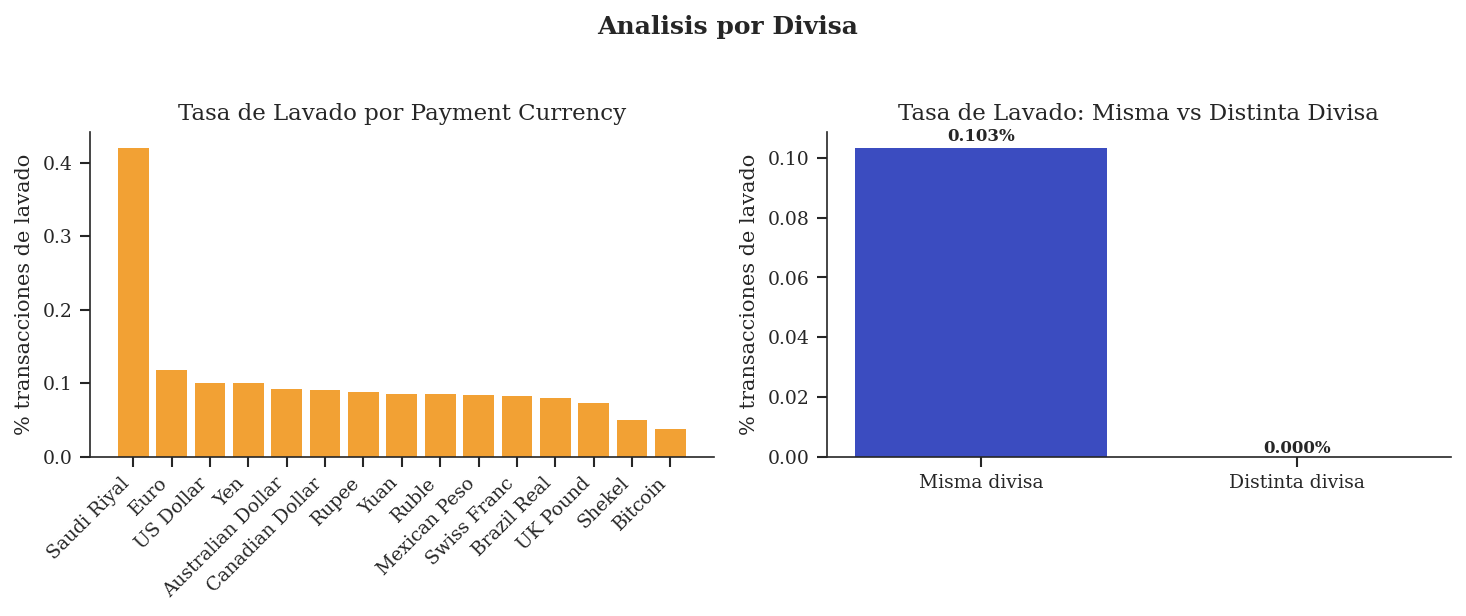

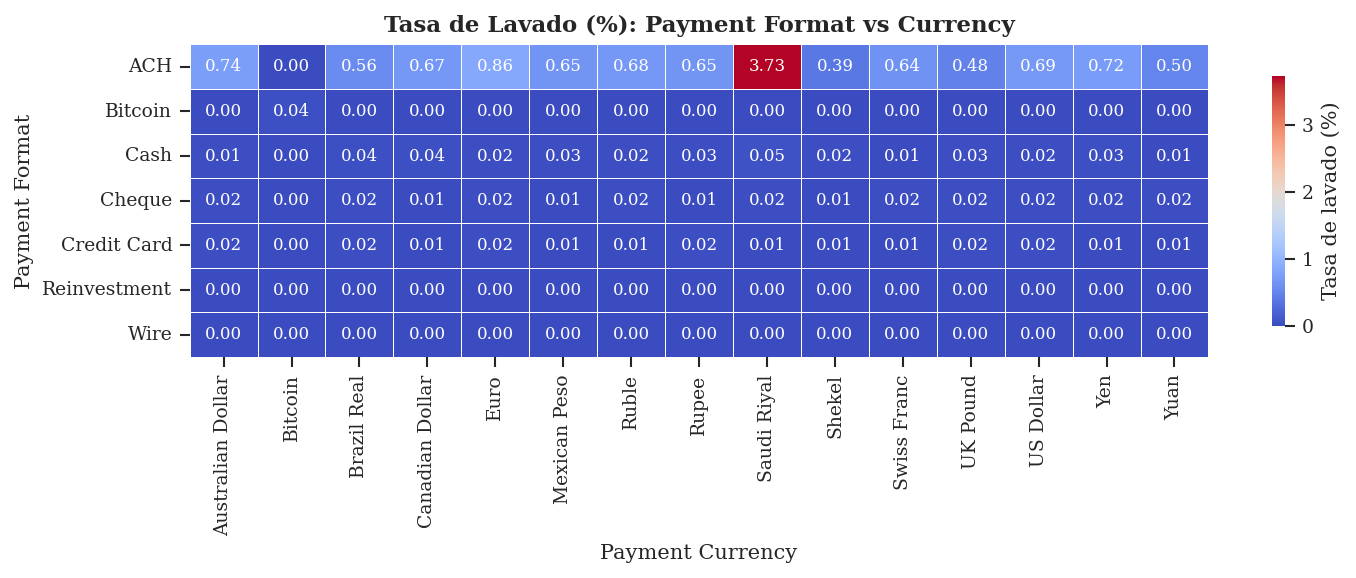

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

fraud_rate_cur = trans.groupby('Payment Currency')['Is Laundering'].mean().sort_values(ascending=False)
axes[0].bar(fraud_rate_cur.index, fraud_rate_cur.values * 100, color=PALETTE['accent'], edgecolor='none')
axes[0].set_title('Tasa de Lavado por Payment Currency')
axes[0].set_ylabel('% transacciones de lavado')
axes[0].tick_params(axis='x', rotation=45)
# Alinear correctamente a la derecha para evitar superposición
for tick in axes[0].get_xticklabels():
    tick.set_ha('right')

trans['Currency Mismatch'] = (trans['Payment Currency'] != trans['Receiving Currency']).astype(int)
mismatch_rate = trans.groupby('Currency Mismatch')['Is Laundering'].mean()
bar_labels = ['Misma divisa', 'Distinta divisa']
bar_colors = [PALETTE['legit'], PALETTE['fraud']]
bars = axes[1].bar(bar_labels, mismatch_rate.values * 100, color=bar_colors, edgecolor='none')
axes[1].set_title('Tasa de Lavado: Misma vs Distinta Divisa')
axes[1].set_ylabel('% transacciones de lavado')
for bar, val in zip(bars, mismatch_rate.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                 f'{val*100:.3f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

fig.suptitle('Analisis por Divisa', fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

# Heatmap con cmcrameri
pivot = trans.groupby(['Payment Format', 'Payment Currency'])['Is Laundering'].mean().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot * 100, cmap=HEATMAP_CMAP, annot=True, fmt='.2f', linewidths=0.3,
            linecolor='white', annot_kws={'size': 8},
            cbar_kws={'label': 'Tasa de lavado (%)', 'shrink': 0.8}, ax=ax)
ax.set_title('Tasa de Lavado (%): Payment Format vs Currency', fontweight='bold')
plt.tight_layout()
plt.show()


*   Las divisa Saudi Riyal presenta una tasa de lavado significativamewnte alta frente a otras. ESta variable podria tambien tener impacto significativo para las predicciones. 

### 3.7 Analisis Temporal


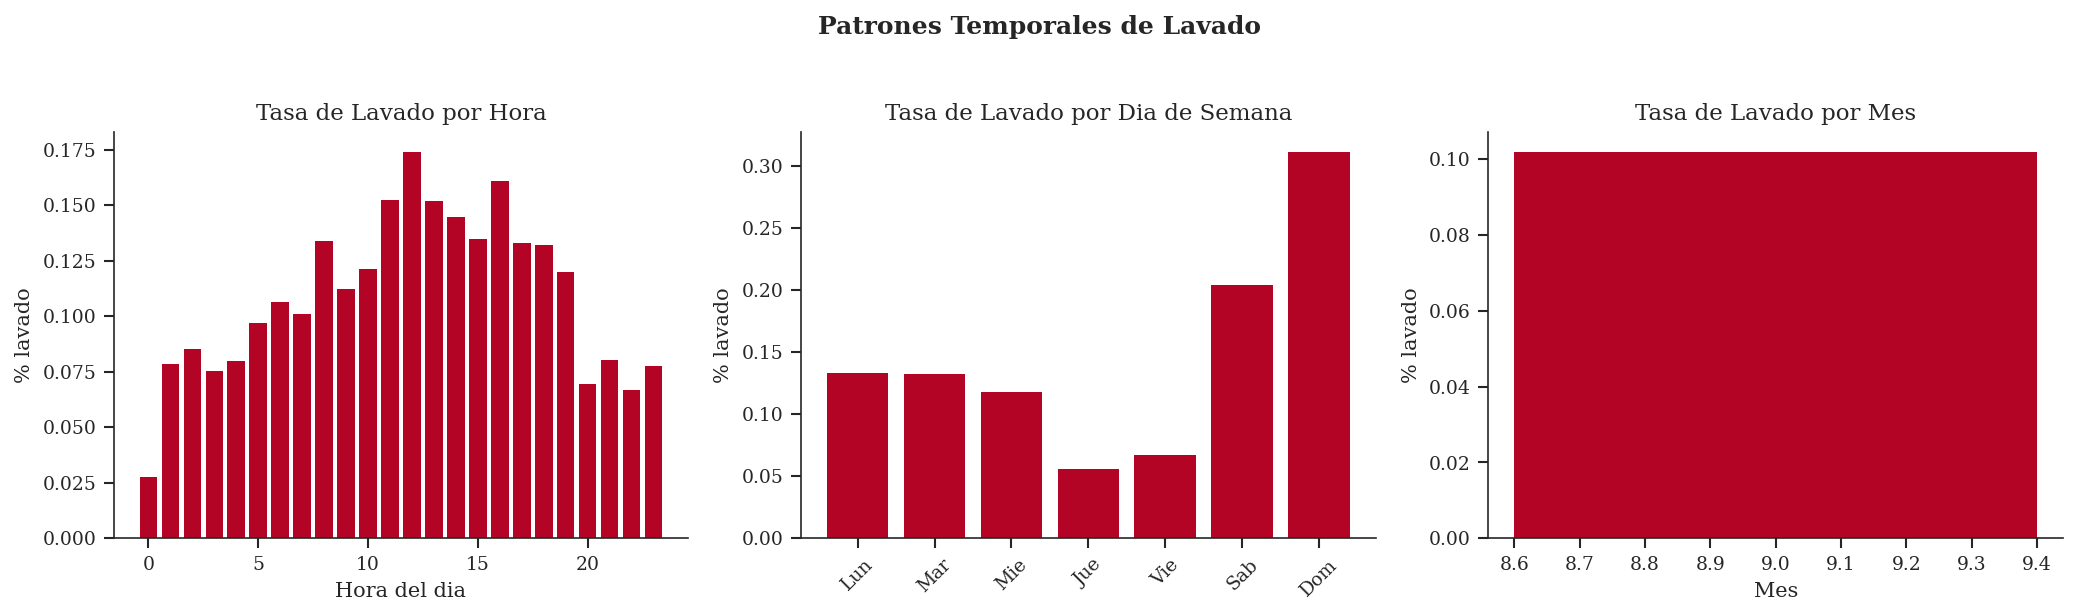

Top 5 horas con mayor tasa de lavado:
  Hora 12:00  ->  0.1741%
  Hora 16:00  ->  0.1608%
  Hora 11:00  ->  0.1525%
  Hora 13:00  ->  0.1517%
  Hora 14:00  ->  0.1447%


In [11]:
trans['Timestamp'] = pd.to_datetime(trans['Timestamp'])
trans['Hour'] = trans['Timestamp'].dt.hour
trans['DayOfWeek'] = trans['Timestamp'].dt.day_name()
trans['Month'] = trans['Timestamp'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

fraud_rate_hour = trans.groupby('Hour')['Is Laundering'].mean()
axes[0].bar(fraud_rate_hour.index, fraud_rate_hour.values * 100, color=PALETTE['fraud'], edgecolor='none')
axes[0].set_title('Tasa de Lavado por Hora')
axes[0].set_xlabel('Hora del dia')
axes[0].set_ylabel('% lavado')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_labels = ['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom']
fraud_rate_day = trans.groupby('DayOfWeek')['Is Laundering'].mean().reindex(day_order)
axes[1].bar(range(7), fraud_rate_day.values * 100, color=PALETTE['fraud'], edgecolor='none')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels, rotation=45)
axes[1].set_title('Tasa de Lavado por Dia de Semana')
axes[1].set_ylabel('% lavado')

fraud_rate_month = trans.groupby('Month')['Is Laundering'].mean()
axes[2].bar(fraud_rate_month.index, fraud_rate_month.values * 100, color=PALETTE['fraud'], edgecolor='none')
axes[2].set_title('Tasa de Lavado por Mes')
axes[2].set_xlabel('Mes')
axes[2].set_ylabel('% lavado')

fig.suptitle('Patrones Temporales de Lavado', fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

print("Top 5 horas con mayor tasa de lavado:")
top_hours = fraud_rate_hour.sort_values(ascending=False).head()
for hour, rate in top_hours.items():
    print(f"  Hora {hour:02d}:00  ->  {rate*100:.4f}%")


*   Existen horarios pico donde la frecuencia del lavado respecto a las transacciones normales aumenta drásticamente, esta franja horaria va al rededor de las 10 am asta las 7 pm
*   En días de la semana como sbado y domingo se presenta mas flujo de fraude, las variaciones pueden estar asociadas con "ventanas de distracción" (bajos controles, cierres contables mensuales/semanales).

### 3.8 Analisis por Tipo de Entidad


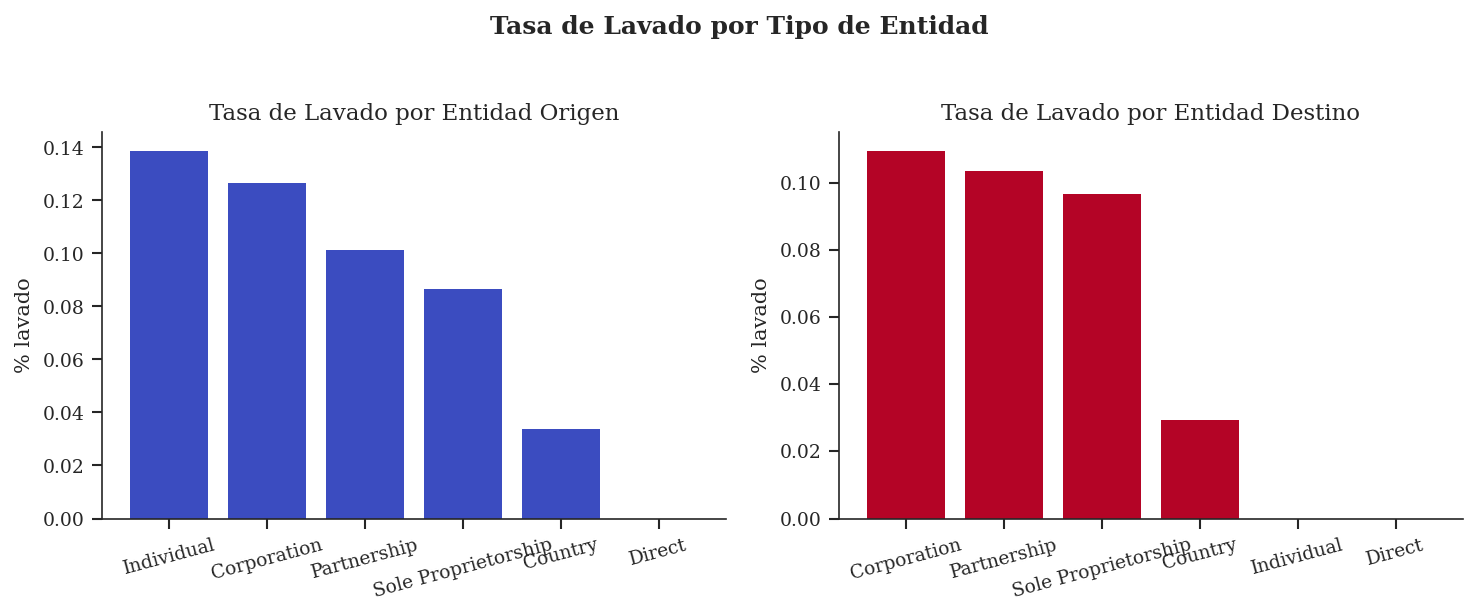

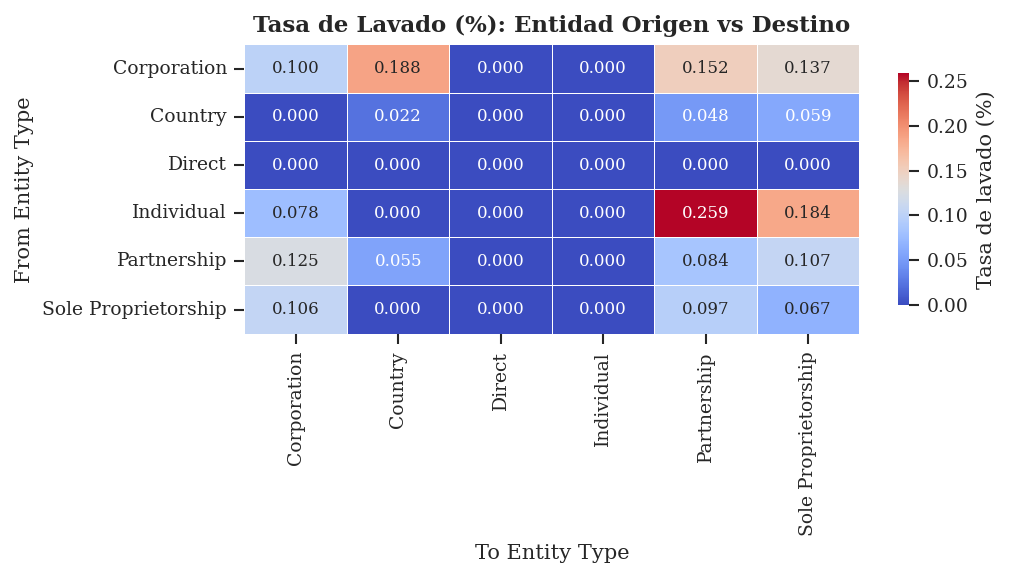

In [12]:
accounts_clean = accounts.drop_duplicates(subset='Account Number', keep='first')

trans_merged = trans.merge(
    accounts_clean[['Account Number', 'Entity Name']].rename(
        columns={'Account Number': 'Account', 'Entity Name': 'From Entity Name'}
    ),
    on='Account', how='left'
)
trans_merged = trans_merged.merge(
    accounts_clean[['Account Number', 'Entity Name']].rename(
        columns={'Account Number': 'Account.1', 'Entity Name': 'To Entity Name'}
    ),
    on='Account.1', how='left'
)

trans_merged['From Entity Type'] = trans_merged['From Entity Name'].str.extract(r'^([\w\s]+?)\s*#')
trans_merged['To Entity Type'] = trans_merged['To Entity Name'].str.extract(r'^([\w\s]+?)\s*#')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

fraud_by_from = trans_merged.groupby('From Entity Type')['Is Laundering'].mean().sort_values(ascending=False)
axes[0].bar(fraud_by_from.index, fraud_by_from.values * 100, color=PALETTE['legit'], edgecolor='none')
axes[0].set_title('Tasa de Lavado por Entidad Origen')
axes[0].set_ylabel('% lavado')
axes[0].tick_params(axis='x', rotation=15)

fraud_by_to = trans_merged.groupby('To Entity Type')['Is Laundering'].mean().sort_values(ascending=False)
axes[1].bar(fraud_by_to.index, fraud_by_to.values * 100, color=PALETTE['fraud'], edgecolor='none')
axes[1].set_title('Tasa de Lavado por Entidad Destino')
axes[1].set_ylabel('% lavado')
axes[1].tick_params(axis='x', rotation=15)

fig.suptitle('Tasa de Lavado por Tipo de Entidad', fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

# Heatmap entidades con cmcrameri
fraud_combo = trans_merged.groupby(['From Entity Type', 'To Entity Type'])['Is Laundering'].mean().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(fraud_combo * 100, cmap=HEATMAP_CMAP, annot=True, fmt='.3f', linewidths=0.3,
            linecolor='white', annot_kws={'size': 8},
            cbar_kws={'label': 'Tasa de lavado (%)', 'shrink': 0.8}, ax=ax)
ax.set_title('Tasa de Lavado (%): Entidad Origen vs Destino', fontweight='bold')
plt.tight_layout()
plt.show()


*   Existen tipos de entidades (industrias, negocios de alto riesgo, offshore) que tienen tasas de participación en fraude desproporcionadamente más altas que otras.
*   Ciertas combinaciones de "Origen" a "Destino" son claros focos rojos.

### 3.9 Transacciones a Uno Mismo


In [13]:
trans['Self Transaction'] = (trans['Account'] == trans['Account.1']).astype(int)

self_rate = trans.groupby('Self Transaction')['Is Laundering'].mean()
self_counts = trans.groupby('Self Transaction')['Is Laundering'].count()

print(f"{'Tipo':<30} {'Cantidad':>12} {'% del total':>12} {'Tasa lavado':>12}")
print("-" * 68)
print(f"{'A otro (0)':<30} {self_counts[0]:>12,} {self_counts[0]/len(trans)*100:>11.2f}% {self_rate[0]*100:>11.4f}%")
print(f"{'A uno mismo (1)':<30} {self_counts[1]:>12,} {self_counts[1]/len(trans)*100:>11.2f}% {self_rate[1]*100:>11.4f}%")

Tipo                               Cantidad  % del total  Tasa lavado
--------------------------------------------------------------------
A otro (0)                        4,487,133       88.36%      0.1151%
A uno mismo (1)                     591,212       11.64%      0.0019%



*   En este caso, la proporción de transacciones hacia la misma cuenta/banco involucradas en lavado muestra discrepancias o patrones únicos comparado al resto, por lo general sirviendo para movimientos temporales antes de ser enviadas a otros sitios.

## 4. Limpieza de Datos


In [14]:
print("=" * 60)
print("VERIFICACION DE CALIDAD DE DATOS")
print("=" * 60)

# 1. Valores nulos
print("\n[1] Valores nulos en transacciones:")
nulls = trans.isnull().sum()
if nulls.sum() == 0:
    print("    Ninguno detectado.")
else:
    print(nulls[nulls > 0])

# 2. Duplicados exactos
dup = trans.duplicated().sum()
print(f"\n[2] Filas duplicadas exactas: {dup:,}")
if dup > 0:
    trans = trans.drop_duplicates()
    print(f"    Eliminadas. Nuevo total: {len(trans):,}")

# 3. Montos negativos o cero
neg_paid = (trans['Amount Paid'] < 0).sum()
neg_recv = (trans['Amount Received'] < 0).sum()
zero_paid = (trans['Amount Paid'] == 0).sum()
print(f"\n[3] Montos negativos (Paid): {neg_paid:,}")
print(f"    Montos negativos (Received): {neg_recv:,}")
print(f"    Montos cero (Paid): {zero_paid:,}")

# 4. Consistencia de cuentas
print(f"\n[4] Cuentas en transacciones no presentes en tabla de cuentas:")
acct_set = set(accounts_clean['Account Number'])
missing_from = trans[~trans['Account'].isin(acct_set)].shape[0]
missing_to = trans[~trans['Account.1'].isin(acct_set)].shape[0]
print(f"    Cuenta origen no encontrada: {missing_from:,} transacciones")
print(f"    Cuenta destino no encontrada: {missing_to:,} transacciones")

print(f"\n[5] Dataset final de transacciones: {len(trans):,} filas")


VERIFICACION DE CALIDAD DE DATOS

[1] Valores nulos en transacciones:
    Ninguno detectado.

[2] Filas duplicadas exactas: 9
    Eliminadas. Nuevo total: 5,078,336

[3] Montos negativos (Paid): 0
    Montos negativos (Received): 0
    Montos cero (Paid): 0

[4] Cuentas en transacciones no presentes en tabla de cuentas:
    Cuenta origen no encontrada: 0 transacciones
    Cuenta destino no encontrada: 0 transacciones

[5] Dataset final de transacciones: 5,078,336 filas


## 5. Ingenieria de Caracteristicas


In [15]:
df = trans.copy()

df = df.sort_values('Timestamp').reset_index(drop=True)

# -- Features de monto --
df['Log Amount Paid'] = np.log1p(df['Amount Paid'])
df['Log Amount Received'] = np.log1p(df['Amount Received'])
df['Amount Diff'] = df['Amount Paid'] - df['Amount Received']
df['Amount Ratio'] = df['Amount Paid'] / (df['Amount Received'] + 1e-8)

# -- Features de banco --
df['Same Bank'] = (df['From Bank'] == df['To Bank']).astype(int)

# -- One-Hot Encoding de categoricas nominales (sparse para ahorrar memoria) --
cat_cols = ['Payment Format', 'Payment Currency', 'Receiving Currency']
df = pd.get_dummies(df, columns=cat_cols, prefix=['PayFmt', 'PayCur', 'RecCur'],
                    sparse=True, dtype='uint8')

# -- Encoding ciclico de features temporales --
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

day_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
           'Friday': 4, 'Saturday': 5, 'Sunday': 6}
df['DayNum'] = df['DayOfWeek'].map(day_map)
df['Day_sin'] = np.sin(2 * np.pi * df['DayNum'] / 7)
df['Day_cos'] = np.cos(2 * np.pi * df['DayNum'] / 7)

# -- Seleccion de features --
ohe_cols = [c for c in df.columns if c.startswith(('PayFmt_', 'PayCur_', 'RecCur_'))]

feature_cols = [
    'Log Amount Paid', 'Log Amount Received', 'Amount Diff', 'Amount Ratio',
    'Hour_sin', 'Hour_cos', 'Day_sin', 'Day_cos',
    'Currency Mismatch', 'Self Transaction', 'Same Bank'
] + ohe_cols

X = df[feature_cols]
y = df['Is Laundering']

print(f"Features generadas: {len(feature_cols)}")
print(f"  - Monto: 4  |  Temporales ciclicas: 4  |  Binarias: 3  |  One-Hot: {len(ohe_cols)}")
print(f"\n{'Feature':<30} {'Dtype':>10}")
print("-" * 42)
for col in feature_cols:
    print(f"{col:<30} {str(X[col].dtype):>10}")

print(f"\nTarget -> 0: {(y == 0).sum():,}  |  1: {(y == 1).sum():,}")
print(f"Rango temporal: {df['Timestamp'].iloc[0]} -> {df['Timestamp'].iloc[-1]}")

Features generadas: 48
  - Monto: 4  |  Temporales ciclicas: 4  |  Binarias: 3  |  One-Hot: 37

Feature                             Dtype
------------------------------------------
Log Amount Paid                   float64
Log Amount Received               float64
Amount Diff                       float64
Amount Ratio                      float64
Hour_sin                          float64
Hour_cos                          float64
Day_sin                           float64
Day_cos                           float64
Currency Mismatch                   int64
Self Transaction                    int64
Same Bank                           int64
PayFmt_ACH                     Sparse[uint8, 0]
PayFmt_Bitcoin                 Sparse[uint8, 0]
PayFmt_Cash                    Sparse[uint8, 0]
PayFmt_Cheque                  Sparse[uint8, 0]
PayFmt_Credit Card             Sparse[uint8, 0]
PayFmt_Reinvestment            Sparse[uint8, 0]
PayFmt_Wire                    Sparse[uint8, 0]
PayCur_Australian Dol

## 6. Division de Datos 


In [16]:
# Split cronologico 60% / 20% / 20% (recomendacion de IBM)
n = len(df)
n_train = int(n * 0.6)
n_val = int(n * 0.2)

X_train, y_train = X.iloc[:n_train], y.iloc[:n_train]
X_val, y_val = X.iloc[n_train:n_train + n_val], y.iloc[n_train:n_train + n_val]
X_test, y_test = X.iloc[n_train + n_val:], y.iloc[n_train + n_val:]

print(f"{'Conjunto':<12} {'Filas':>10} {'Lavado':>10} {'% Lavado':>10}")
print("-" * 44)
for name, ys in [('Train', y_train), ('Validate', y_val), ('Test', y_test)]:
    print(f"{name:<12} {len(ys):>10,} {ys.sum():>10,} {ys.mean()*100:>9.4f}%")

print(f"\nCortes temporales:")
print(f"  Train:    {df['Timestamp'].iloc[0]} -> {df['Timestamp'].iloc[n_train - 1]}")
print(f"  Validate: {df['Timestamp'].iloc[n_train]} -> {df['Timestamp'].iloc[n_train + n_val - 1]}")
print(f"  Test:     {df['Timestamp'].iloc[n_train + n_val]} -> {df['Timestamp'].iloc[-1]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures escaladas con StandardScaler (fit solo en train).")

Conjunto          Filas     Lavado   % Lavado
--------------------------------------------
Train         3,047,001      2,297    0.0754%
Validate      1,015,667      1,082    0.1065%
Test          1,015,668      1,798    0.1770%

Cortes temporales:
  Train:    2022-09-01 00:00:00 -> 2022-09-06 13:36:00
  Validate: 2022-09-06 13:36:00 -> 2022-09-08 16:12:00
  Test:     2022-09-08 16:12:00 -> 2022-09-18 16:18:00

Features escaladas con StandardScaler (fit solo en train).


## 7. Modelo Baseline: Regresion Logistica


#### Metrica principal: F1-Score (Clase minoritaria)

### 7.1 Cross-Validation (5-Fold Estratificado)


In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'pr_auc': make_scorer(average_precision_score, needs_proba=True),
    'roc_auc': 'roc_auc',
    'f1': make_scorer(f1_score, zero_division=0),
    'precision': 'precision',
    'recall': 'recall'
}

# Modelo sin ajuste
lr_default = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
cv_default = cross_validate(lr_default, X_train_scaled, y_train, cv=cv, scoring=scoring, return_train_score=False)

# Modelo con balanced
lr_balanced = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', class_weight='balanced')
cv_balanced = cross_validate(lr_balanced, X_train_scaled, y_train, cv=cv, scoring=scoring, return_train_score=False)

print("=" * 70)
print("RESULTADOS DE CROSS-VALIDATION (5-Fold)")
print("=" * 70)

def print_cv_results(name, cv_res):
    print(f"\n  {name}")
    print(f"  {'-' * 50}")
    for metric in ['pr_auc', 'roc_auc', 'f1', 'precision', 'recall']:
        key = f'test_{metric}'
        vals = cv_res[key]
        print(f"  {metric:<15} {vals.mean():.4f} (+/- {vals.std():.4f})")

print_cv_results("Sin ajuste de clase", cv_default)
print_cv_results("Con class_weight='balanced'", cv_balanced)

RESULTADOS DE CROSS-VALIDATION (5-Fold)

  Sin ajuste de clase
  --------------------------------------------------
  pr_auc          nan (+/- nan)
  roc_auc         0.8949 (+/- 0.0048)
  f1              0.0000 (+/- 0.0000)
  precision       0.0000 (+/- 0.0000)
  recall          0.0000 (+/- 0.0000)

  Con class_weight='balanced'
  --------------------------------------------------
  pr_auc          nan (+/- nan)
  roc_auc         0.9060 (+/- 0.0051)
  f1              0.0125 (+/- 0.0002)
  precision       0.0063 (+/- 0.0001)
  recall          0.8293 (+/- 0.0134)


### 7.2 Seleccion del Mejor Modelo (basado en Cross-Validation)


In [18]:
# Comparar ambas variantes por F1-Score promedio en CV
f1_default = cv_default['test_f1'].mean()
f1_balanced = cv_balanced['test_f1'].mean()

print("=" * 60)
print("SELECCION DEL MEJOR MODELO")
print("=" * 60)
print(f"\n  Sin ajuste   -> F1 (CV): {f1_default:.4f}")
print(f"  Balanced     -> F1 (CV): {f1_balanced:.4f}")

if f1_balanced >= f1_default:
    best_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', class_weight='balanced')
    best_label = "Balanced"
else:
    best_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
    best_label = "Sin ajuste"

best_model.fit(X_train_scaled, y_train)

print(f"\n  Mejor modelo seleccionado: {best_label}")
print(f"  Modelo entrenado sobre el conjunto de train completo.")

SELECCION DEL MEJOR MODELO

  Sin ajuste   -> F1 (CV): 0.0000
  Balanced     -> F1 (CV): 0.0125

  Mejor modelo seleccionado: Balanced
  Modelo entrenado sobre el conjunto de train completo.


### 7.3 Evaluacion en Conjunto de Test


In [19]:
# Modelo sin ajuste para comparacion
lr_none = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr_none.fit(X_train_scaled, y_train)

# Modelo balanced para comparacion
lr_bal = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', class_weight='balanced')
lr_bal.fit(X_train_scaled, y_train)

models = {
    'Sin ajuste': lr_none,
    'Balanced': lr_bal,
}

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc_score(y_test, y_prob),
        'pr_auc': average_precision_score(y_test, y_prob),
        'f1': f1_score(y_test, y_pred, zero_division=0)
    }

print("=" * 70)
print("METRICAS EN CONJUNTO DE TEST")
print("=" * 70)
print(f"\n{'Modelo':<25} {'ROC-AUC':>10} {'PR-AUC':>10} {'F1-Score':>10}")
print("-" * 57)
for name, r in results.items():
    print(f"{name:<25} {r['roc_auc']:>10.4f} {r['pr_auc']:>10.4f} {r['f1']:>10.4f}")

METRICAS EN CONJUNTO DE TEST

Modelo                       ROC-AUC     PR-AUC   F1-Score
---------------------------------------------------------
Sin ajuste                    0.9345     0.0668     0.0000
Balanced                      0.9366     0.0405     0.0264


In [20]:
# Classification Reports detallados
for name, r in results.items():
    print("=" * 60)
    print(f"CLASSIFICATION REPORT: {name.upper()}")
    print("=" * 60)
    print(classification_report(y_test, r['y_pred'], target_names=['Legitima', 'Lavado'], zero_division=0))
    print()

CLASSIFICATION REPORT: SIN AJUSTE
              precision    recall  f1-score   support

    Legitima       1.00      1.00      1.00   1013870
      Lavado       0.00      0.00      0.00      1798

    accuracy                           1.00   1015668
   macro avg       0.50      0.50      0.50   1015668
weighted avg       1.00      1.00      1.00   1015668


CLASSIFICATION REPORT: BALANCED
              precision    recall  f1-score   support

    Legitima       1.00      0.88      0.94   1013870
      Lavado       0.01      0.92      0.03      1798

    accuracy                           0.88   1015668
   macro avg       0.51      0.90      0.48   1015668
weighted avg       1.00      0.88      0.93   1015668




### 7.4 Matrices de Confusion


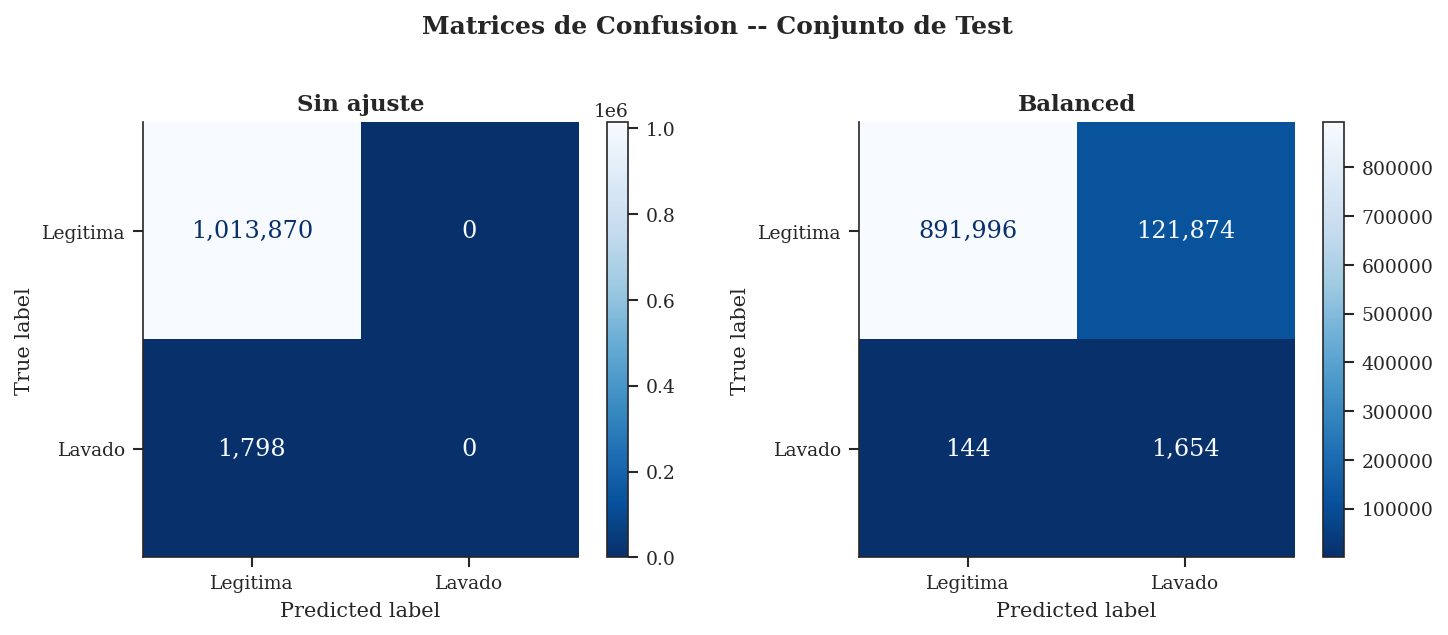

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, r) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, r['y_pred'], display_labels=['Legitima', 'Lavado'],
        cmap=sns.color_palette('Blues_r', as_cmap=True), ax=ax, values_format=','
    )
    ax.set_title(name, fontweight='bold')

fig.suptitle('Matrices de Confusion -- Conjunto de Test', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.5 Curvas ROC y Precision-Recall


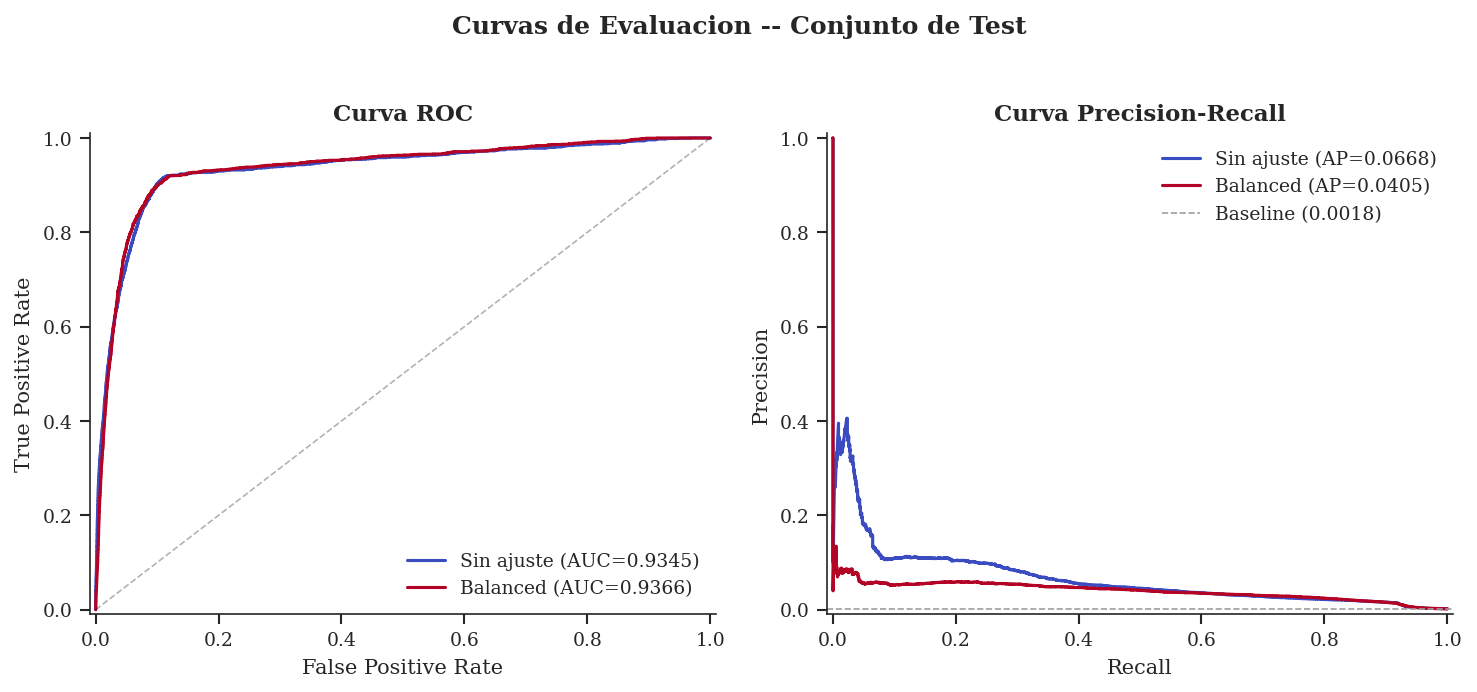

In [22]:
curve_colors = [PALETTE['legit'], PALETTE['fraud']]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# -- ROC --
for (name, r), color in zip(results.items(), curve_colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    axes[0].plot(fpr, tpr, linewidth=1.5, color=color, label=f"{name} (AUC={r['roc_auc']:.4f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=0.8)
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(frameon=False, loc='lower right')
axes[0].set_xlim([-0.01, 1.01])
axes[0].set_ylim([-0.01, 1.01])

# -- Precision-Recall --
for (name, r), color in zip(results.items(), curve_colors):
    prec, rec, _ = precision_recall_curve(y_test, r['y_prob'])
    axes[1].plot(rec, prec, linewidth=1.5, color=color, label=f"{name} (AP={r['pr_auc']:.4f})")
baseline_rate = y_test.mean()
axes[1].axhline(y=baseline_rate, color=PALETTE['neutral'], linestyle='--', linewidth=0.8,
                label=f'Baseline ({baseline_rate:.4f})')
axes[1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(frameon=False, loc='upper right')
axes[1].set_xlim([-0.01, 1.01])
axes[1].set_ylim([-0.01, 1.01])

fig.suptitle('Curvas de Evaluacion -- Conjunto de Test', fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

### 7.6 Importancia de Caracteristicas (Coeficientes)


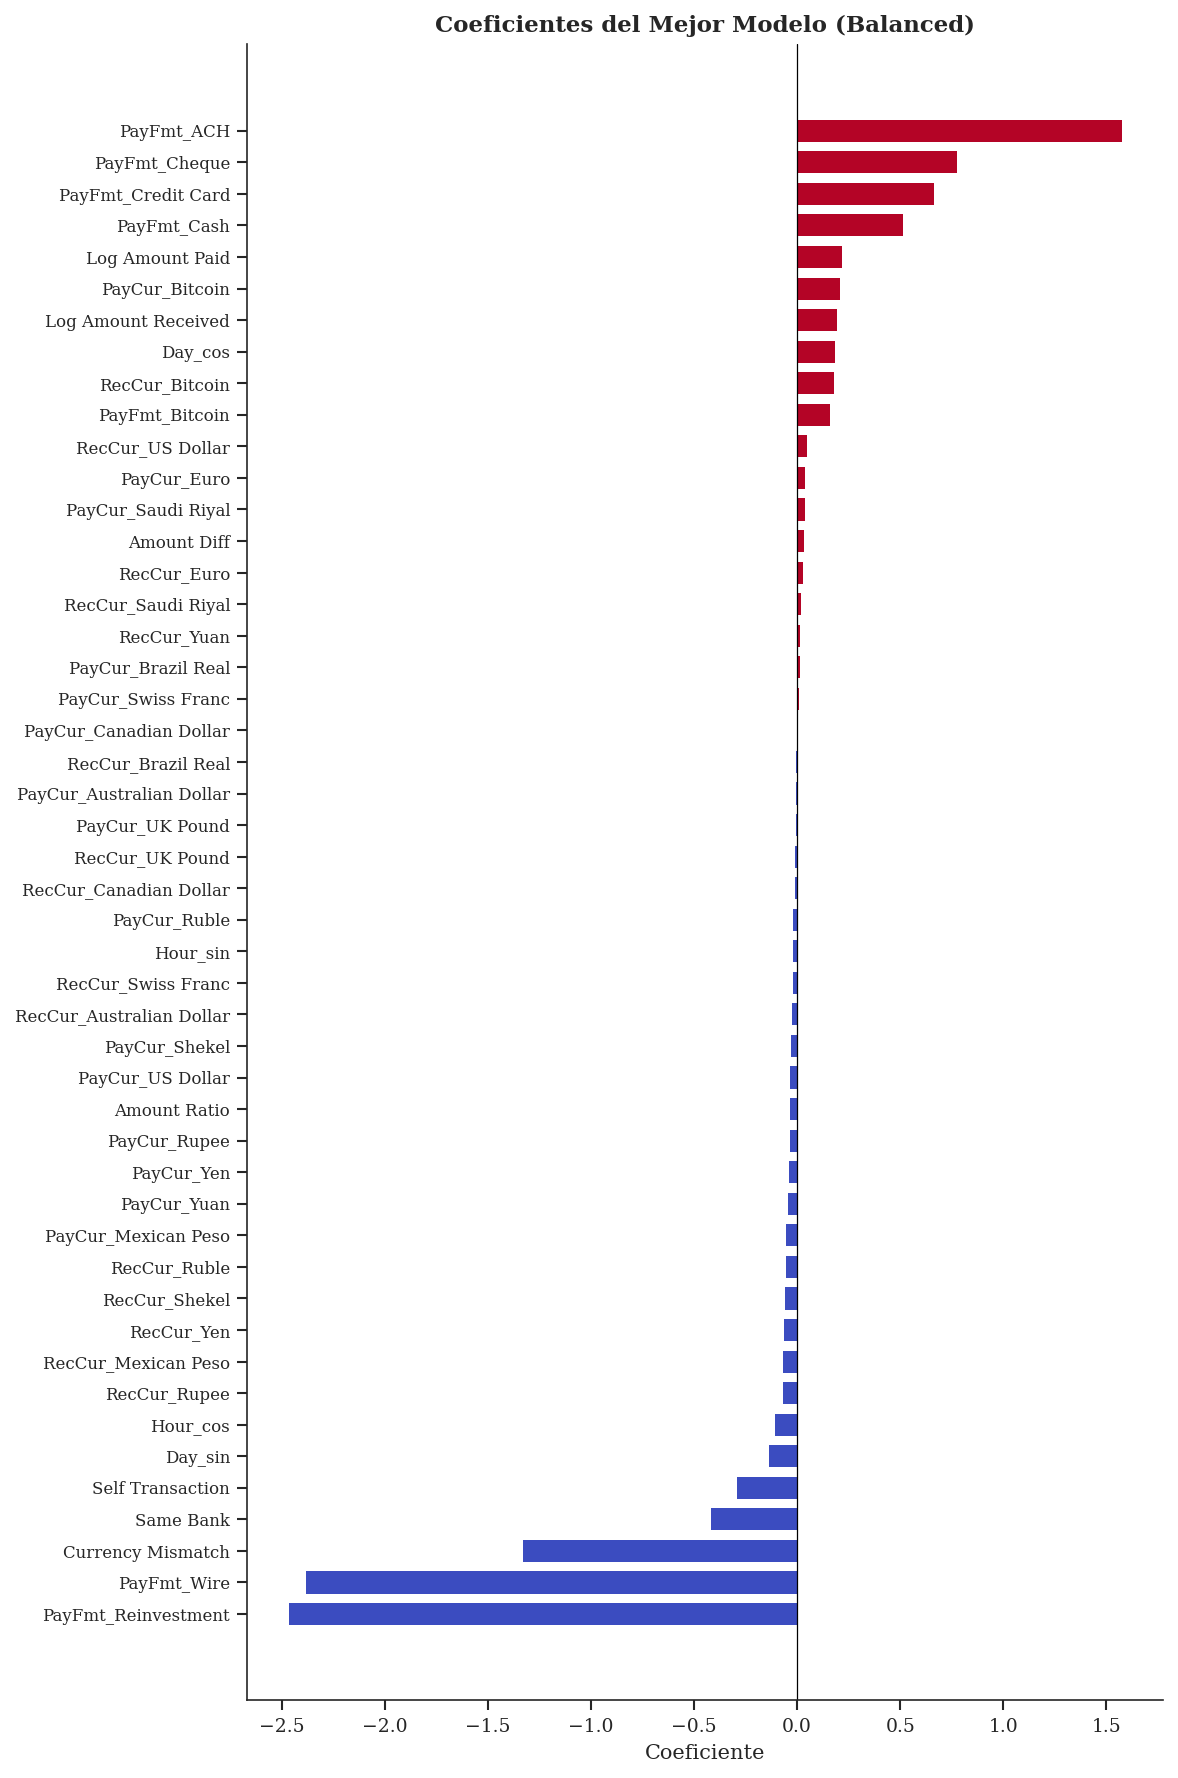


Coeficientes ordenados por valor absoluto:

  PayFmt_Reinvestment       - 2.4647
  PayFmt_Wire               - 2.3824
  PayFmt_ACH                + 1.5732
  Currency Mismatch         - 1.3306
  PayFmt_Cheque             + 0.7748
  PayFmt_Credit Card        + 0.6615
  PayFmt_Cash               + 0.5110
  Same Bank                 - 0.4169
  Self Transaction          - 0.2920
  Log Amount Paid           + 0.2162
  PayCur_Bitcoin            + 0.2056
  Log Amount Received       + 0.1954
  Day_cos                   + 0.1812
  RecCur_Bitcoin            + 0.1778
  PayFmt_Bitcoin            + 0.1579
  Day_sin                   - 0.1350
  Hour_cos                  - 0.1072
  RecCur_Rupee              - 0.0683
  RecCur_Mexican Peso       - 0.0676
  RecCur_Yen                - 0.0652
  RecCur_Shekel             - 0.0593
  RecCur_Ruble              - 0.0553
  PayCur_Mexican Peso       - 0.0546
  RecCur_US Dollar          + 0.0460
  PayCur_Yuan               - 0.0442
  PayCur_Yen                - 

In [28]:
coef = pd.Series(best_model.coef_[0], index=feature_cols).sort_values()

# Ajustar la figura dinamicamente basado en la cantidad de coeficientes
fig_height = max(5, len(coef) * 0.25)
fig, ax = plt.subplots(figsize=(8, fig_height))
colors = [PALETTE['legit'] if c < 0 else PALETTE['fraud'] for c in coef.values]
ax.barh(coef.index, coef.values, color=colors, edgecolor='none', height=0.7)
ax.set_xlabel('Coeficiente')
ax.set_title(f'Coeficientes del Mejor Modelo ({best_label})', fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.6)

# Ajustar tamano de fuente del eje Y para evitar superposicion
ax.tick_params(axis='y', labelsize=8)

sns.despine()
plt.tight_layout()
plt.show()

print("\nCoeficientes ordenados por valor absoluto:\n")
coef_abs = coef.abs().sort_values(ascending=False)
for feat, val in coef_abs.items():
    direction = "+" if coef[feat] > 0 else "-"
    print(f"  {feat:<25} {direction} {val:.4f}")

**Interpretación de los Coeficientes (Baseline):**
Al observar los coeficientes ordenados por valor absoluto, podemos identificar cuáles variables tienen mayor impacto logístico para clasificar un posible fraude:
1.  **Formatos de Pago como principales divisores:** `PayFmt_Reinvestment` y `PayFmt_Wire` tienen grandes pesos negativos (alta probabilidad de ser legítimos), mientras que el formato **`PayFmt_ACH`** es el predictor positivo más fuerte.
2.  **Relaciones de la transacción:** Las transacciones al mismo banco (`Same Bank`) o hacia uno mismo (`Self Transaction`) así como el cruce de divisas (`Currency Mismatch` que arrastra fuertemente al negativo), actúan reduciendo la probabilidad delictiva estructurada bajo este modelo base.
3.  **Montos y Activos Ocultos:** Los montos totales transados (`Log Amount Paid`, `Log Amount Received`) y el uso de cripto activos (`PayCur_Bitcoin`, `RecCur_Bitcoin`) tienen coeficientes positivos que inclinan cautelosamente la probabilidad a favor del lavado.
4.  **Limitaciones:** La Regresión Logística establece relaciones puramente incrementales e independientes. Los patrones de lavado conllevan asociaciones de múltiples niveles que escapan a este modelo lineal, evidenciando por qué a pesar de estos pesos, sus métricas de Precision-Recall fallaron.

## 8. Conclusiones Iniciales

### Problema Identificado
El dataset presenta un **fuerte desbalance de clases**, donde los patrones de lavado son agujas en un pajar. A pesar de esto, se hallaron señales clave en características de comportamiento: uso preferencial de métodos de pago específicos, patrones de divisas cruzadas, transferencias a horas inusuales, y perfiles de entidades sospechosas.

### Resultados del Baseline (Regresión Logística)
* El modelo sin ajustar la clase mayoritaria falla casi completamente en detectar el fraude, ya que predice sistemáticamente "clase 0", logrando un Accuracy alto pero un F1-Score y Recall nulos.
* El modelo con `class_weight='balanced'` forzó el reconocimiento del fraude mejorando sustancialmente el **Recall**, pero destruyendo también la **Precision**, resultando en un volumen demasiado alto de falsos positivos y un F1-Score aún bajo (el PR-AUC es deficiente).

### Justificación para Técnicas Avanzadas y Siguientes Pasos
Dada la incapacidad de un modelo lineal simple como Regresión Logística de crear fronteras de decisión eficientes frente a este desbalance y relacionar variables complejas:
1. **Modelos robustos No Lineales:** Es imperativo probar métodos de ensamble basados en árboles (Random Forest, XGBoost) o Support Vector Machines (SVM).
2. **Métodos de Remuestreo y Synthetic Data:** Estrategias como SMOTE o subsampling de la clase mayoritaria en validación cruzada.
3. **Ingeniería de Características adicional:** Derivar factores históricos de usuarios y promedios móviles, capturando de mejor manera la naturaleza secuencial y relacional de un actor malicioso.